In [1]:
# Import necessary libraries
import optuna
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Pima Indian Diabetes dataset from sklearn
# Note: Scikit-learn's built-in 'load_diabetes' is a regression dataset.
# We will load the actual diabetes dataset from an external source
import pandas as pd

# Load the Pima Indian Diabetes dataset (from UCI repository)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
           'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset
df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
import numpy as np

# Replace zero values with NaN in columns where zero is not a valid value
cols_with_missing_vals = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_missing_vals] = df[cols_with_missing_vals].replace(0, np.nan)

# Impute the missing values with the mean of the respective column
df.fillna(df.mean(), inplace=True)

# Check if there are any remaining missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [3]:
# Split into features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split data into training and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Optional: Scale the data for better model performance
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Check the shape of the data
print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')

Training set shape: (537, 8)
Test set shape: (231, 8)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize

In [5]:
# Create a study object and optimize the objective function
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters


[I 2026-09-10 20:13:53,937] A new study created in memory with name: no-name-1964121a-8da5-428c-996b-2dda90e51673
[I 2026-09-10 20:13:54,504] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 113, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-09-10 20:13:55,331] Trial 1 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 177, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-09-10 20:13:55,781] Trial 2 finished with value: 0.7709497206703911 and parameters: {'n_estimators': 100, 'max_depth': 8}. Best is trial 2 with value: 0.7709497206703911.
[I 2026-09-10 20:13:56,626] Trial 3 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 180, 'max_depth': 17}. Best is trial 3 with value: 0.7728119180633147.
[I 2026-09-10 20:13:57,425] Trial 4 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 184, 'max_depth': 4}. Best is trial 3 with value: 0.772811

In [6]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7821229050279331
Best hyperparameters: {'n_estimators': 73, 'max_depth': 20}


In [7]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')

Test Accuracy with best hyperparameters: 0.75


# Samplers in Optuna

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Define the objective function
def objective(trial):
    # Suggest values for the hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 200)
    max_depth = trial.suggest_int('max_depth', 3, 20)

    # Create the RandomForestClassifier with suggested hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # Perform 3-fold cross-validation and calculate accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

    return score  # Return the accuracy score for Optuna to maximize

In [9]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.RandomSampler())  # We aim to maximize accuracy
study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

[I 2026-09-10 20:14:21,437] A new study created in memory with name: no-name-7ab28eed-379c-41fa-99ef-09b83f61f254
[I 2026-09-10 20:14:22,013] Trial 0 finished with value: 0.7635009310986964 and parameters: {'n_estimators': 116, 'max_depth': 11}. Best is trial 0 with value: 0.7635009310986964.
[I 2026-09-10 20:14:22,372] Trial 1 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 75, 'max_depth': 5}. Best is trial 1 with value: 0.7690875232774674.
[I 2026-09-10 20:14:22,918] Trial 2 finished with value: 0.7765363128491621 and parameters: {'n_estimators': 113, 'max_depth': 16}. Best is trial 2 with value: 0.7765363128491621.
[I 2026-09-10 20:14:23,853] Trial 3 finished with value: 0.7802607076350093 and parameters: {'n_estimators': 194, 'max_depth': 17}. Best is trial 3 with value: 0.7802607076350093.
[I 2026-09-10 20:14:24,199] Trial 4 finished with value: 0.7616387337057727 and parameters: {'n_estimators': 70, 'max_depth': 12}. Best is trial 3 with value: 0.7802607

In [10]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7858472998137803
Best hyperparameters: {'n_estimators': 121, 'max_depth': 15}


In [11]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')

Test Accuracy with best hyperparameters: 0.76


In [12]:
search_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20]
}

In [13]:
# Create a study and optimize it using GridSampler
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.GridSampler(search_space))
study.optimize(objective)

[I 2026-09-10 20:14:49,338] A new study created in memory with name: no-name-78952e90-9ddc-43e4-8ff8-cfa0280a4590
[I 2026-09-10 20:14:49,789] Trial 0 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 5}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-09-10 20:14:50,467] Trial 1 finished with value: 0.7672253258845437 and parameters: {'n_estimators': 150, 'max_depth': 10}. Best is trial 0 with value: 0.7690875232774674.
[I 2026-09-10 20:14:50,718] Trial 2 finished with value: 0.7728119180633147 and parameters: {'n_estimators': 50, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-09-10 20:14:51,221] Trial 3 finished with value: 0.7653631284916201 and parameters: {'n_estimators': 100, 'max_depth': 15}. Best is trial 2 with value: 0.7728119180633147.
[I 2026-09-10 20:14:51,696] Trial 4 finished with value: 0.7690875232774674 and parameters: {'n_estimators': 100, 'max_depth': 20}. Best is trial 2 with value: 0.772811

In [14]:
# Print the best result
print(f'Best trial accuracy: {study.best_trial.value}')
print(f'Best hyperparameters: {study.best_trial.params}')

Best trial accuracy: 0.7746741154562384
Best hyperparameters: {'n_estimators': 50, 'max_depth': 5}


In [15]:
from sklearn.metrics import accuracy_score

# Train a RandomForestClassifier using the best hyperparameters from Optuna
best_model = RandomForestClassifier(**study.best_trial.params, random_state=42)

# Fit the model to the training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate the accuracy on the test set
test_accuracy = accuracy_score(y_test, y_pred)

# Print the test accuracy
print(f'Test Accuracy with best hyperparameters: {test_accuracy:.2f}')

Test Accuracy with best hyperparameters: 0.74


# Optuna Visualizations

In [16]:
# For visualizations
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

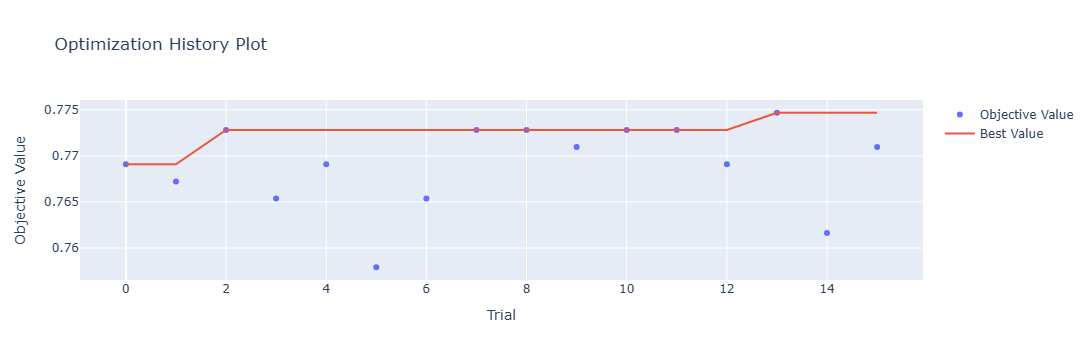

In [17]:
# 1. Optimization History
plot_optimization_history(study).show()

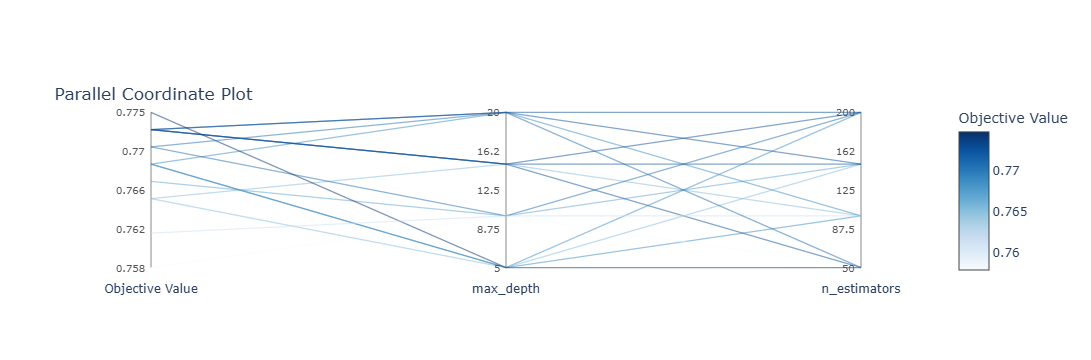

In [18]:
# 2. Parallel Coordinates Plot
plot_parallel_coordinate(study).show()

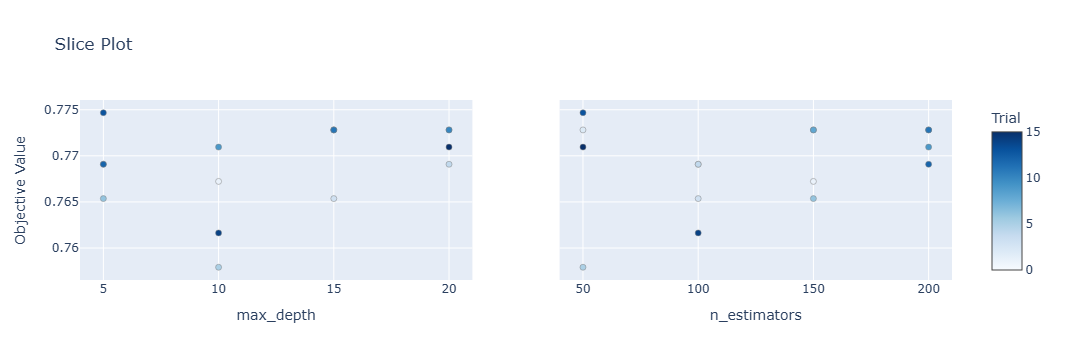

In [19]:
# 3. Slice Plot
plot_slice(study).show()

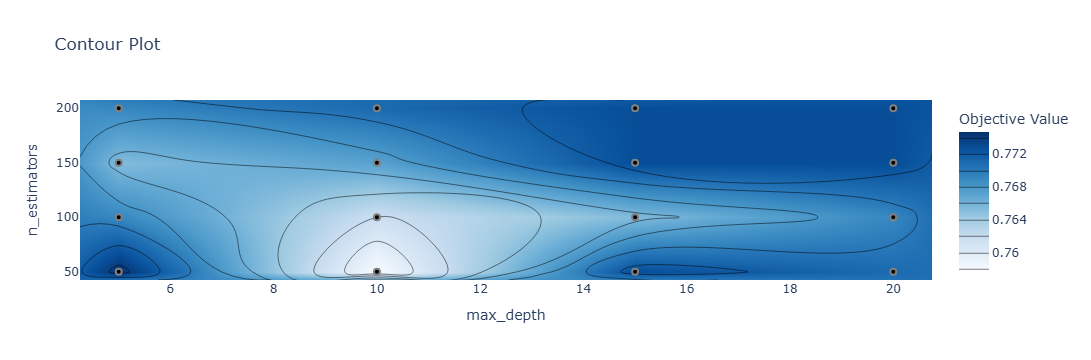

In [20]:
# 4. Contour Plot
plot_contour(study).show()

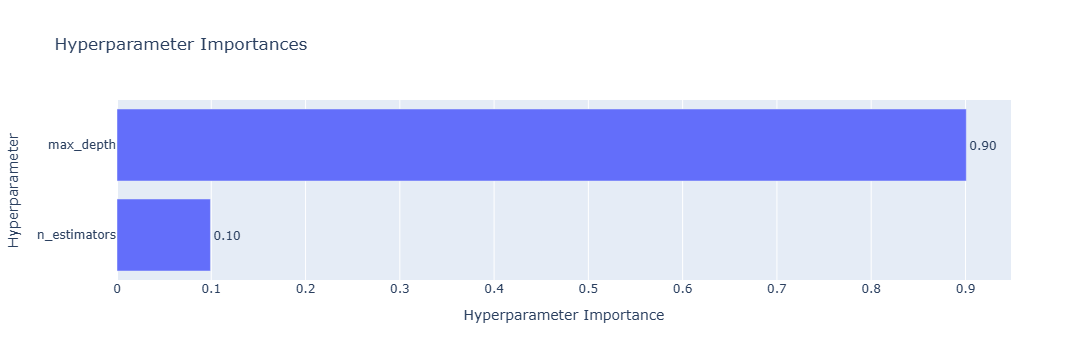

In [21]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

# Optimizing Multiple ML Models

In [22]:
# Importing the required libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [23]:
# Define the objective function for Optuna
def objective(trial):
    # Choose the algorithm to tune
    classifier_name = trial.suggest_categorical('classifier', ['SVM', 'RandomForest', 'GradientBoosting'])

    if classifier_name == 'SVM':
        # SVM hyperparameters
        c = trial.suggest_float('C', 0.1, 100, log=True)
        kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
        gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

        model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=42)

    elif classifier_name == 'RandomForest':
        # Random Forest hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )

    elif classifier_name == 'GradientBoosting':
        # Gradient Boosting hyperparameters
        n_estimators = trial.suggest_int('n_estimators', 50, 300)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )

    # Perform cross-validation and return the mean accuracy
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

In [24]:
# Create a study and optimize it using CmaEsSampler
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2026-09-10 20:15:02,496] A new study created in memory with name: no-name-c6ae5cea-d905-4bca-bc3e-206da80363fa
[I 2026-09-10 20:15:03,166] Trial 0 finished with value: 0.7635009310986964 and parameters: {'classifier': 'GradientBoosting', 'n_estimators': 69, 'learning_rate': 0.2929483453283428, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.7635009310986964.
[I 2026-09-10 20:15:04,033] Trial 1 finished with value: 0.7783985102420857 and parameters: {'classifier': 'RandomForest', 'n_estimators': 245, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 7, 'bootstrap': False}. Best is trial 1 with value: 0.7783985102420857.
[I 2026-09-10 20:15:04,055] Trial 2 finished with value: 0.7001862197392924 and parameters: {'classifier': 'SVM', 'C': 61.012881809082465, 'kernel': 'sigmoid', 'gamma': 'auto'}. Best is trial 1 with value: 0.7783985102420857.
[I 2026-09-10 20:15:05,228] Trial 3 finished with value: 0.7541899441340782 and paramete

In [25]:
# Retrieve the best trial
best_trial = study.best_trial
print("Best trial parameters:", best_trial.params)
print("Best trial accuracy:", best_trial.value)

Best trial parameters: {'classifier': 'SVM', 'C': 0.1372396588118256, 'kernel': 'linear', 'gamma': 'scale'}
Best trial accuracy: 0.7895716945996275


In [26]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_C,params_bootstrap,params_classifier,params_gamma,params_kernel,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_n_estimators,system_attrs_tpe:relative_params:0,state
0,0,0.763501,2026-09-10 20:15:02.499291,2026-09-10 20:15:03.166586,0 days 00:00:00.667295,NaN,NaN,GradientBoosting,NaN,NaN,0.292948,9.0,7.0,7.0,69.0,NaN,COMPLETE
1,1,0.778399,2026-09-10 20:15:03.167473,2026-09-10 20:15:04.033358,0 days 00:00:00.865885,NaN,False,RandomForest,NaN,NaN,NaN,7.0,7.0,9.0,245.0,NaN,COMPLETE
2,2,0.700186,2026-09-10 20:15:04.034332,2026-09-10 20:15:04.055500,0 days 00:00:00.021168,61.012882,NaN,SVM,auto,sigmoid,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
3,3,0.754190,2026-09-10 20:15:04.056453,2026-09-10 20:15:05.227919,0 days 00:00:01.171466,NaN,NaN,GradientBoosting,NaN,NaN,0.055194,4.0,3.0,2.0,253.0,NaN,COMPLETE
4,4,0.756052,2026-09-10 20:15:05.228900,2026-09-10 20:15:05.264009,0 days 00:00:00.035109,14.250124,NaN,SVM,auto,rbf,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,0.715084,2026-09-10 20:15:33.603832,2026-09-10 20:15:33.628850,0 days 00:00:00.025018,0.159521,NaN,SVM,scale,poly,NaN,NaN,NaN,NaN,NaN,"{""classifier"": ""SVM""}",COMPLETE
96,96,0.746741,2026-09-10 20:15:33.629761,2026-09-10 20:15:34.263897,0 days 00:00:00.634136,NaN,NaN,GradientBoosting,NaN,NaN,0.126124,3.0,2.0,6.0,169.0,"{""classifier"": ""GradientBoosting""}",COMPLETE
97,97,0.789572,2026-09-10 20:15:34.264795,2026-09-10 20:15:34.289044,0 days 00:00:00.024249,0.130954,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,"{""classifier"": ""SVM""}",COMPLETE
98,98,0.785847,2026-09-10 20:15:34.289946,2026-09-10 20:15:34.316379,0 days 00:00:00.026433,0.278706,NaN,SVM,scale,linear,NaN,NaN,NaN,NaN,NaN,"{""classifier"": ""SVM""}",COMPLETE


In [27]:
study.trials_dataframe()['params_classifier'].value_counts()

params_classifier
SVM                 70
RandomForest        20
GradientBoosting    10
Name: count, dtype: int64

In [28]:
study.trials_dataframe().groupby('params_classifier')['value'].mean()

params_classifier
GradientBoosting    0.740596
RandomForest        0.769553
SVM                 0.778053
Name: value, dtype: float64

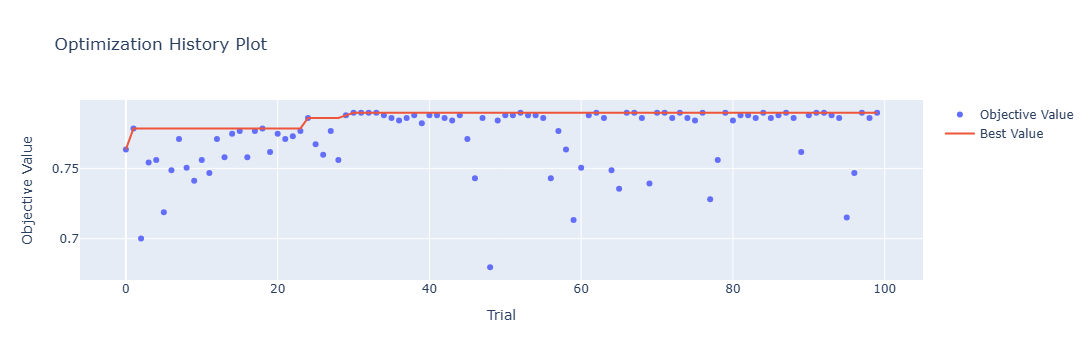

In [29]:
# 1. Optimization History
plot_optimization_history(study).show()

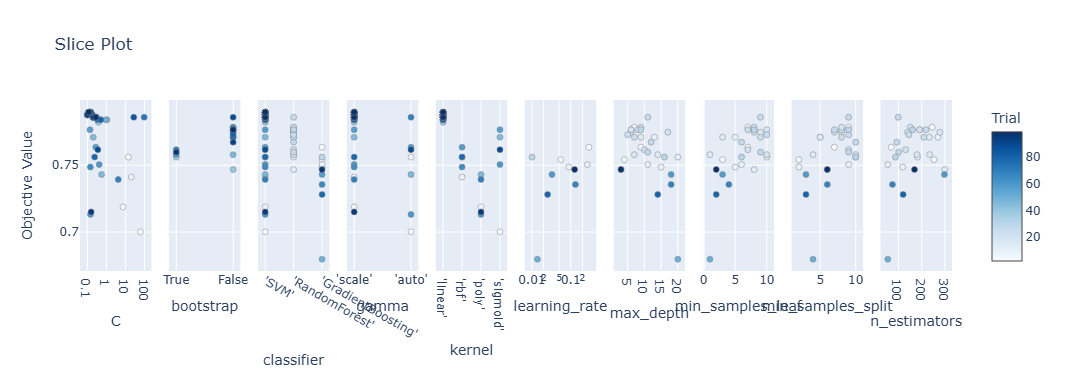

In [30]:
# 3. Slice Plot
plot_slice(study).show()

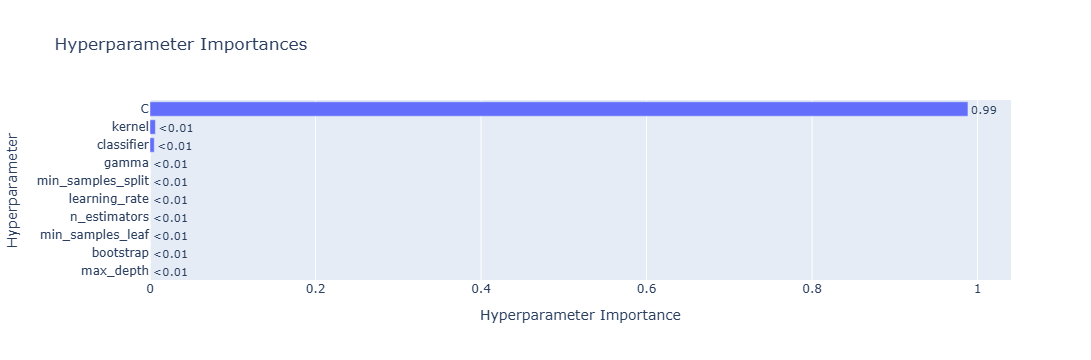

In [31]:
# 5. Hyperparameter Importance
plot_param_importances(study).show()

In [32]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np

# Load the Iris dataset
X, y = load_iris(return_X_y=True)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the objective function for XGBoost
def objective(trial):
    # Hyperparameter search space
    param = {
        'verbosity': 0,
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',  # Ensure that the eval_metric is specified here
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'n_estimators': 300,
    }

    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Define a pruning callback based on evaluation metrics
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "eval-mlogloss")  # Match the metric name in the evals list

    # Train the model
    bst = xgb.train(
        param,
        dtrain,
        num_boost_round=300,
        evals=[(dtrain, "train"), (dtest, "eval")],  # Ensure the eval datasets and names are specified
        early_stopping_rounds=30,
        callbacks=[pruning_callback]
    )

    # Predict on the test set
    preds = bst.predict(dtest)
    best_preds = [int(np.argmax(line)) for line in preds]

    # Return accuracy as the objective value
    accuracy = accuracy_score(y_test, best_preds)
    return accuracy

# Create a study with pruning
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.SuccessiveHalvingPruner())
study.optimize(objective, n_trials=50)

# Output the best trial
print(f"Best trial: {study.best_trial.params}")
print(f"Best accuracy: {study.best_value}")

[I 2026-09-10 20:15:35,053] A new study created in memory with name: no-name-3d6f8488-dfed-4403-8fb8-1e4b2db22784


[0]	train-mlogloss:0.85349	eval-mlogloss:0.84779
[1]	train-mlogloss:0.65436	eval-mlogloss:0.64231
[2]	train-mlogloss:0.58100	eval-mlogloss:0.57304
[3]	train-mlogloss:0.52632	eval-mlogloss:0.52462
[4]	train-mlogloss:0.44556	eval-mlogloss:0.43886
[5]	train-mlogloss:0.41310	eval-mlogloss:0.40649
[6]	train-mlogloss:0.34128	eval-mlogloss:0.31945
[7]	train-mlogloss:0.31392	eval-mlogloss:0.28555
[8]	train-mlogloss:0.28466	eval-mlogloss:0.25469
[9]	train-mlogloss:0.25852	eval-mlogloss:0.22510
[10]	train-mlogloss:0.25504	eval-mlogloss:0.22446
[11]	train-mlogloss:0.23057	eval-mlogloss:0.19685
[12]	train-mlogloss:0.22081	eval-mlogloss:0.18831
[13]	train-mlogloss:0.20966	eval-mlogloss:0.17218
[14]	train-mlogloss:0.20705	eval-mlogloss:0.16920
[15]	train-mlogloss:0.20393	eval-mlogloss:0.16676
[16]	train-mlogloss:0.20222	eval-mlogloss:0.16409
[17]	train-mlogloss:0.20115	eval-mlogloss:0.16493
[18]	train-mlogloss:0.19937	eval-mlogloss:0.16271
[19]	train-mlogloss:0.19645	eval-mlogloss:0.15687
[20]	train

C:\Users\shrey\AppData\Local\Programs\Python\Python313\Lib\importlib\__init__.py:88: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


[29]	train-mlogloss:0.16725	eval-mlogloss:0.11799
[30]	train-mlogloss:0.16674	eval-mlogloss:0.11759
[31]	train-mlogloss:0.16586	eval-mlogloss:0.11727
[32]	train-mlogloss:0.16586	eval-mlogloss:0.11728
[33]	train-mlogloss:0.16587	eval-mlogloss:0.11727
[34]	train-mlogloss:0.16553	eval-mlogloss:0.11709
[35]	train-mlogloss:0.16552	eval-mlogloss:0.11715
[36]	train-mlogloss:0.16543	eval-mlogloss:0.11673
[37]	train-mlogloss:0.16545	eval-mlogloss:0.11666
[38]	train-mlogloss:0.16544	eval-mlogloss:0.11674
[39]	train-mlogloss:0.16542	eval-mlogloss:0.11674
[40]	train-mlogloss:0.16454	eval-mlogloss:0.11641
[41]	train-mlogloss:0.16435	eval-mlogloss:0.11604
[42]	train-mlogloss:0.16435	eval-mlogloss:0.11604
[43]	train-mlogloss:0.16435	eval-mlogloss:0.11606
[44]	train-mlogloss:0.16436	eval-mlogloss:0.11604
[45]	train-mlogloss:0.16437	eval-mlogloss:0.11610
[46]	train-mlogloss:0.16437	eval-mlogloss:0.11620
[47]	train-mlogloss:0.16422	eval-mlogloss:0.11591
[48]	train-mlogloss:0.16420	eval-mlogloss:0.11580


[I 2026-09-10 20:15:35,694] Trial 0 finished with value: 1.0 and parameters: {'lambda': 5.749727568398229e-08, 'alpha': 3.4204738094703963e-07, 'eta': 0.24299526267590088, 'gamma': 0.04266021168307356, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.9510532210258607, 'colsample_bytree': 0.4504436585616899}. Best is trial 0 with value: 1.0.


...

[0]	train-mlogloss:0.96902	eval-mlogloss:0.96662


[I 2026-09-10 20:15:40,548] Trial 48 pruned. Trial was pruned at iteration 1.


[0]	train-mlogloss:0.99922	eval-mlogloss:0.99357
[1]	train-mlogloss:0.91257	eval-mlogloss:0.90476
[2]	train-mlogloss:0.83766	eval-mlogloss:0.82453
[3]	train-mlogloss:0.77237	eval-mlogloss:0.75645


[I 2026-09-10 20:15:40,602] Trial 49 pruned. Trial was pruned at iteration 4.


Best trial: {'lambda': 5.749727568398229e-08, 'alpha': 3.4204738094703963e-07, 'eta': 0.24299526267590088, 'gamma': 0.04266021168307356, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.9510532210258607, 'colsample_bytree': 0.4504436585616899}
Best accuracy: 1.0


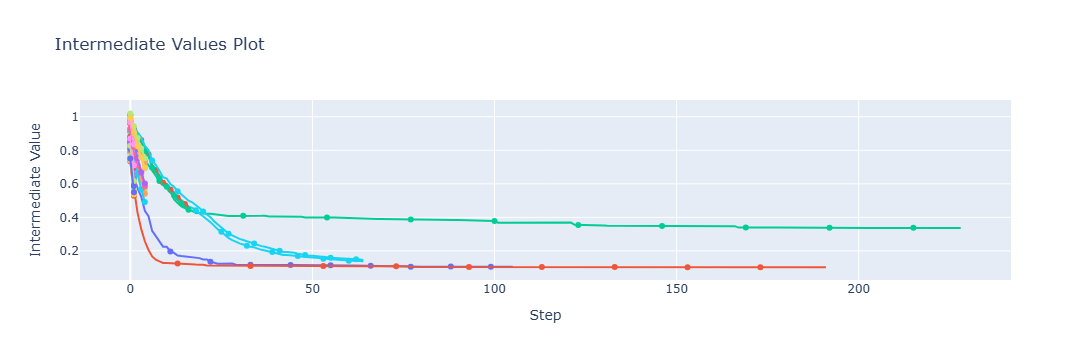

In [33]:
from optuna.visualization import plot_intermediate_values

# 1. Plot intermediate values during the trials
plot_intermediate_values(study).show()